In [ ]:
!pip install optuna xgboost lightgbm catboost

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import optuna
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_param_importances
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [5]:
df = pd.read_csv("Data Sheet.csv")

In [6]:
df.head()

,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Gender,Vehicle_Type,Number_of_Lanes,Lane_Width,Road_Type,Alcohol_Consumption,Crash_Type,Seatbelt_Usage,Speed_Limit,Road_Surface_Condition
0,Minor injury,107,11,27,Male,Heavy Vehicle,2,3.484386,Urban,Yes,Rear-end,No,30,Icy
1,Minor injury,27,16,39,Male,Car,2,3.293091,Rural,Yes,Rear-end,Yes,110,Dry
2,Minor injury,87,14,42,Female,Car,3,3.218911,Urban,No,Rear-end,No,59,Dry
3,Minor injury,43,3,60,Female,Heavy Vehicle,2,3.113012,Rural,No,Rear-end,No,73,Wet
4,Minor injury,72,8,70,Male,T.W,3,3.106580,Urban,Yes,Rear-end,Yes,42,Wet


In [7]:
df.shape

(300, 14)

# Exploratory Data Analysis (EDA)

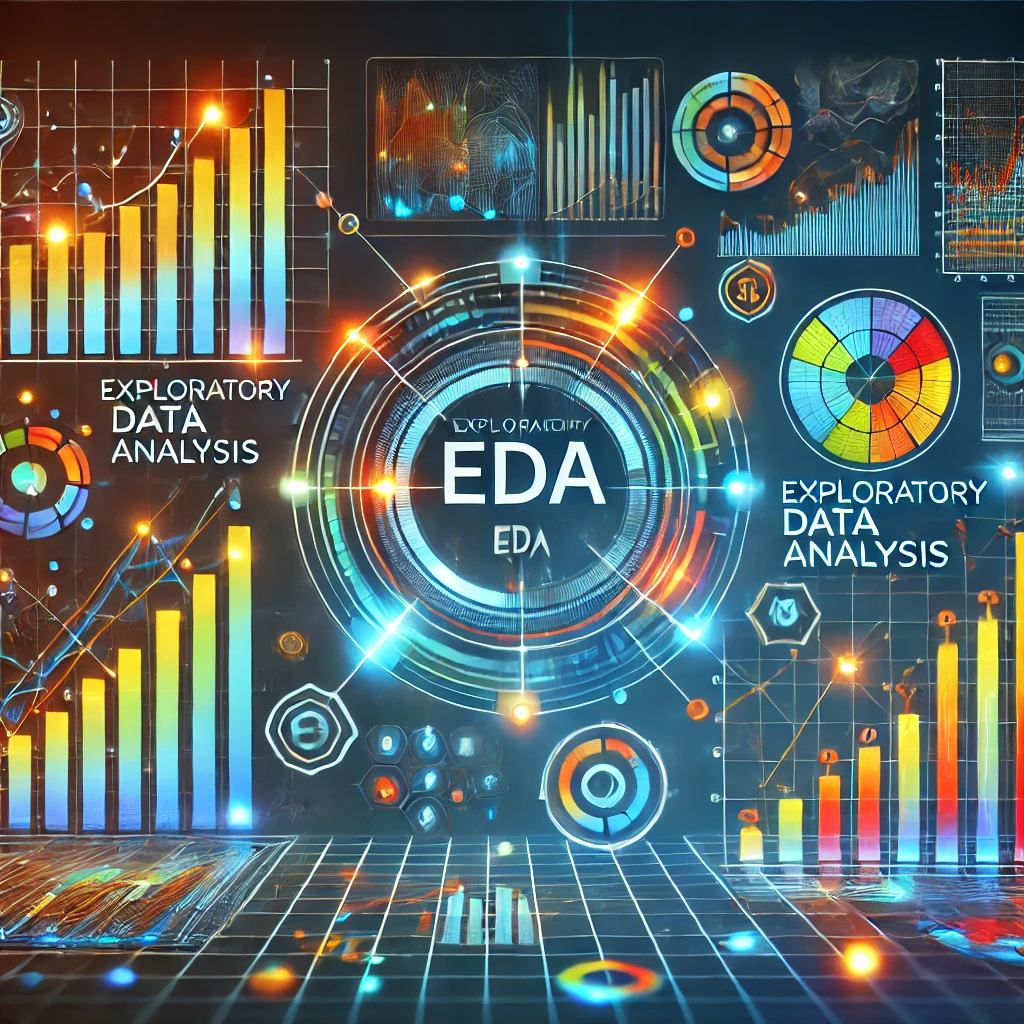

**Data Insights**

In [8]:
df.isnull().sum()

Crash_Severity            0
Vehicle_Speed             0
Crash_Time                0
Age                       0
Gender                    0
Vehicle_Type              0
Number_of_Lanes           0
Lane_Width                0
Road_Type                 0
Alcohol_Consumption       0
Crash_Type                0
Seatbelt_Usage            0
Speed_Limit               0
Road_Surface_Condition    0
dtype: int64

In [9]:
df.nunique()

Crash_Severity              3
Vehicle_Speed             105
Crash_Time                 24
Age                        62
Gender                      2
Vehicle_Type                3
Number_of_Lanes             3
Lane_Width                300
Road_Type                   2
Alcohol_Consumption         2
Crash_Type                  2
Seatbelt_Usage              2
Speed_Limit                85
Road_Surface_Condition      3
dtype: int64

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Crash_Severity          300 non-null    str    
 1   Vehicle_Speed           300 non-null    int64  
 2   Crash_Time              300 non-null    int64  
 3   Age                     300 non-null    int64  
 4   Gender                  300 non-null    str    
 5   Vehicle_Type            300 non-null    str    
 6   Number_of_Lanes         300 non-null    int64  
 7   Lane_Width              300 non-null    float64
 8   Road_Type               300 non-null    str    
 9   Alcohol_Consumption     300 non-null    str    
 10  Crash_Type              300 non-null    str    
 11  Seatbelt_Usage          300 non-null    str    
 12  Speed_Limit             300 non-null    int64  
 13  Road_Surface_Condition  300 non-null    str    
dtypes: float64(1), int64(5), str(8)
memory usage: 32.9 KB

In [11]:
df.describe()

,Vehicle_Speed,Crash_Time,Age,Number_of_Lanes,Lane_Width,Speed_Limit
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,64.366667,11.690000,48.663333,2.000000,3.272374,74.746667
std,31.951974,6.740327,18.432104,0.825999,0.143053,26.857903
min,10.000000,0.000000,18.000000,1.000000,3.001781,30.000000
25%,37.000000,5.750000,31.000000,1.000000,3.150568,51.000000
50%,60.500000,12.000000,51.000000,2.000000,3.285620,75.000000
75%,94.000000,17.000000,65.000000,3.000000,3.394545,97.250000
max,120.000000,23.000000,80.000000,3.000000,3.497986,120.000000


In [12]:
df.head()

,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Gender,Vehicle_Type,Number_of_Lanes,Lane_Width,Road_Type,Alcohol_Consumption,Crash_Type,Seatbelt_Usage,Speed_Limit,Road_Surface_Condition
0,Minor injury,107,11,27,Male,Heavy Vehicle,2,3.484386,Urban,Yes,Rear-end,No,30,Icy
1,Minor injury,27,16,39,Male,Car,2,3.293091,Rural,Yes,Rear-end,Yes,110,Dry
2,Minor injury,87,14,42,Female,Car,3,3.218911,Urban,No,Rear-end,No,59,Dry
3,Minor injury,43,3,60,Female,Heavy Vehicle,2,3.113012,Rural,No,Rear-end,No,73,Wet
4,Minor injury,72,8,70,Male,T.W,3,3.106580,Urban,Yes,Rear-end,Yes,42,Wet


In [13]:
crash_severity_counts = df['Crash_Severity'].value_counts()
crash_severity_counts

Crash_Severity
Minor injury    100
Major injury    100
Fatal crash     100
Name: count, dtype: int64

## Feature Engineering

In [14]:
# Define the bins for the ranges
bins = [0, 30, 60, 90, 120]

# Create the 'Vehicle Speed Range' column
df['Vehicle_Speed_Range'] = pd.cut(df['Vehicle_Speed'], bins=bins, labels=['0-30', '30-60', '60-90', '90-120'], include_lowest=True)

In [15]:
bins = [18, 30, 40, 50, 60, 70, 80]

# Create the 'Age Range' column
df['Age_Range'] = pd.cut(df['Age'], bins=bins, labels=['18-30', '30-40', '40-50', '50-60', '60-70', '70-80'], include_lowest=True)

In [16]:
# Define the bins for the ranges
bins = [3, 3.1, 3.2, 3.3, 3.4, 3.5]

# Create the 'Lane_Width_Range' column using pd.cut
df['Lane_Width_Range'] = pd.cut(df['Lane_Width'], bins=bins, labels=['3-3.1', '3.1-3.2', '3.2-3.3', '3.3-3.4', '3.4-3.5'], include_lowest=True)

In [17]:
df['Over_Speeding'] = df['Vehicle_Speed'] - df['Speed_Limit']

In [18]:
df['Over_Speeding_binary'] = np.where(df['Over_Speeding'] > 0, 1, 0)

In [19]:
df.head()

,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Gender,Vehicle_Type,Number_of_Lanes,Lane_Width,Road_Type,Alcohol_Consumption,Crash_Type,Seatbelt_Usage,Speed_Limit,Road_Surface_Condition,Vehicle_Speed_Range,Age_Range,Lane_Width_Range,Over_Speeding,Over_Speeding_binary
0,Minor injury,107,11,27,Male,Heavy Vehicle,2,3.484386,Urban,Yes,Rear-end,No,30,Icy,90-120,18-30,3.4-3.5,77,1
1,Minor injury,27,16,39,Male,Car,2,3.293091,Rural,Yes,Rear-end,Yes,110,Dry,0-30,30-40,3.2-3.3,-83,0
2,Minor injury,87,14,42,Female,Car,3,3.218911,Urban,No,Rear-end,No,59,Dry,60-90,40-50,3.2-3.3,28,1
3,Minor injury,43,3,60,Female,Heavy Vehicle,2,3.113012,Rural,No,Rear-end,No,73,Wet,30-60,50-60,3.1-3.2,-30,0
4,Minor injury,72,8,70,Male,T.W,3,3.106580,Urban,Yes,Rear-end,Yes,42,Wet,60-90,60-70,3.1-3.2,30,1


## The Correlation Matrix

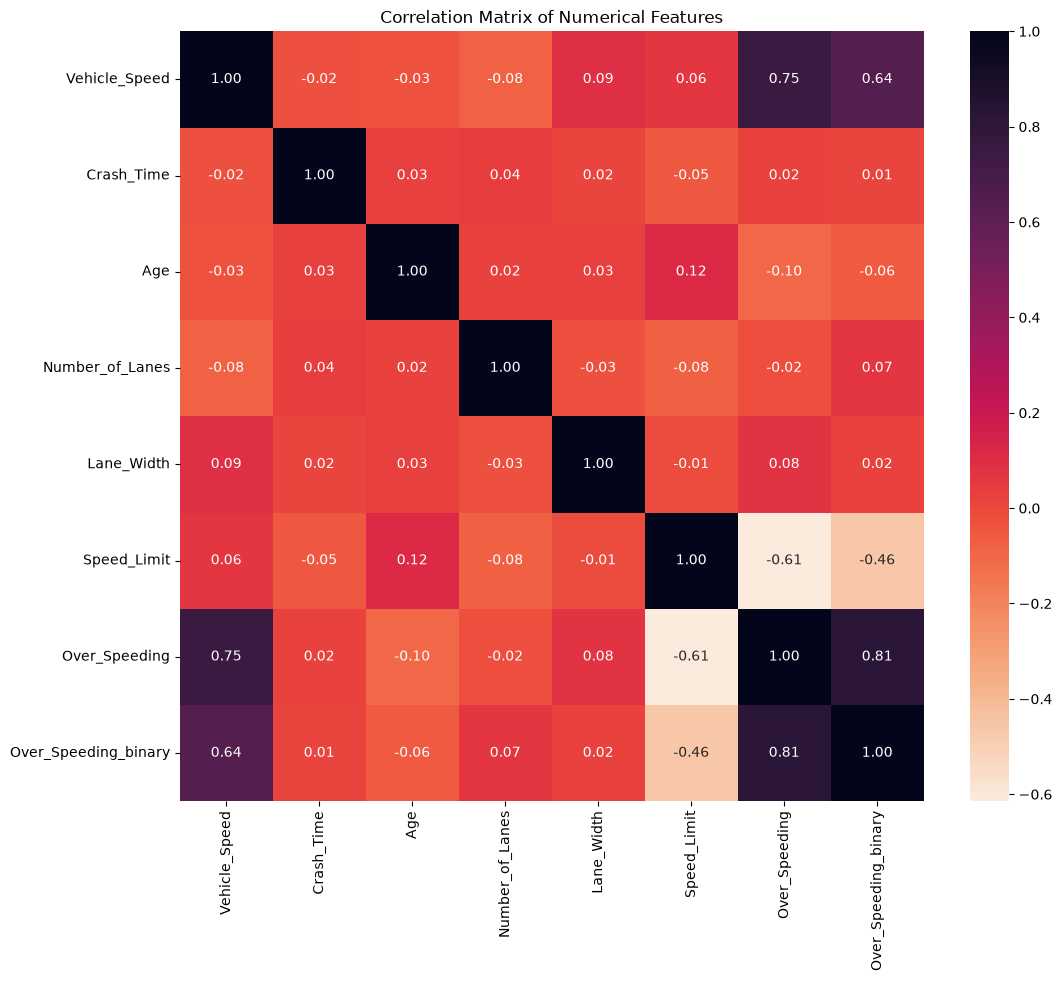

In [20]:
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='rocket_r', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()


## IMPORTANT GRAPHS

**BOX PLOT OF Vehicle speed by Crash Severity**

C:\Users\Adarsh Rai\AppData\Local\Temp\ipykernel_4692\552455175.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Crash_Severity', y='Vehicle_Speed',palette='rocket_r')


<Axes: xlabel='Crash_Severity', ylabel='Vehicle_Speed'>

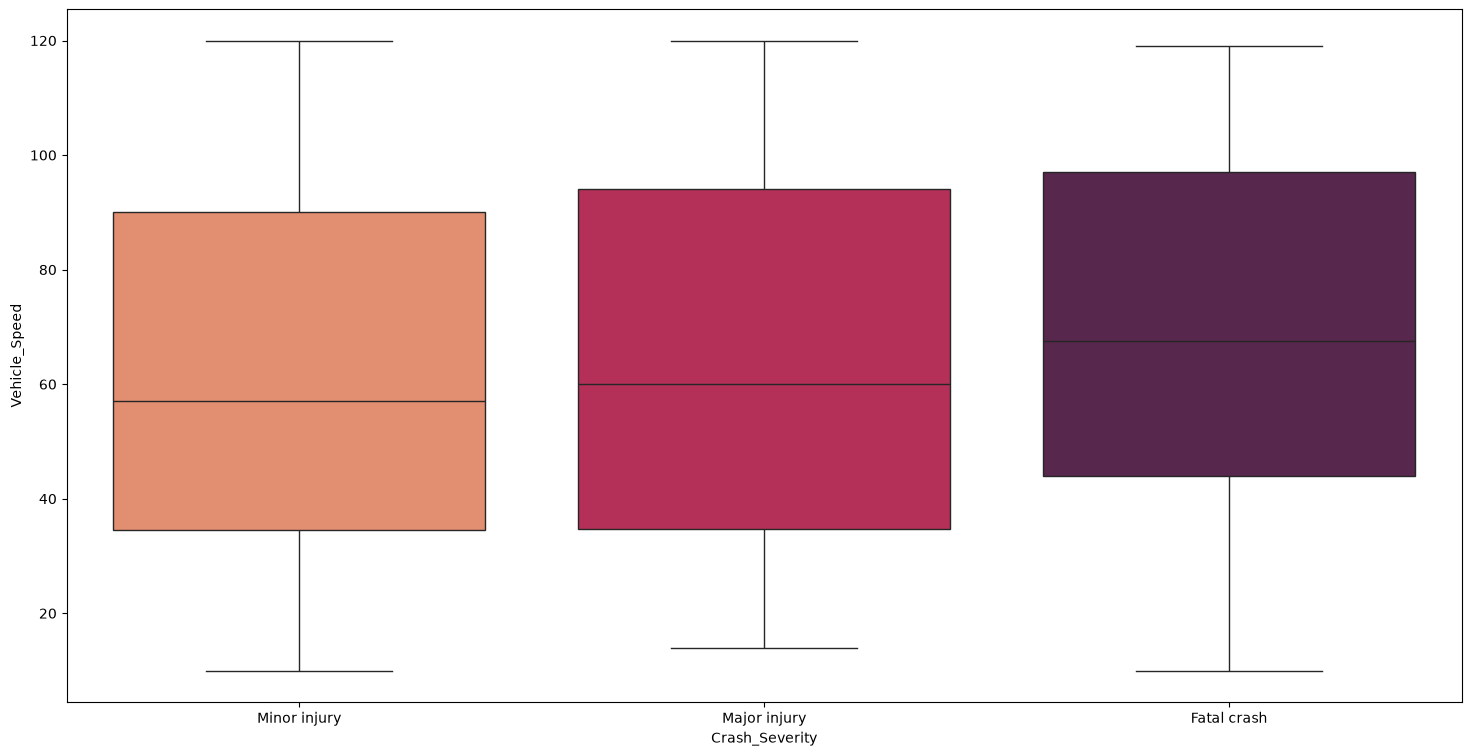

In [24]:
plt.figure(figsize=(18, 9))
sns.boxplot(data=df, x='Crash_Severity', y='Vehicle_Speed',palette='rocket_r')

### Number of Crashes vs. Crash Time Plot

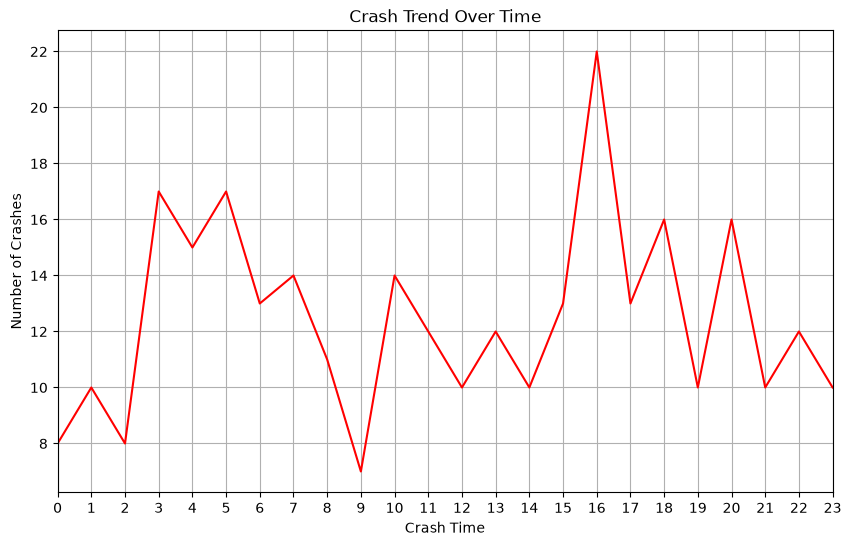

In [25]:
time_series_data = df.groupby('Crash_Time')['Crash_Severity'].count()

plt.figure(figsize=(10, 6))
plt.plot(time_series_data.index, time_series_data.values,color='red')
plt.title('Crash Trend Over Time')
plt.xlabel('Crash Time')
plt.ylabel('Number of Crashes')
plt.grid(True)
plt.xlim(0, 23)
plt.xticks(range(24))
plt.show()

### Vehicle Speed vs. Crash Time Plot

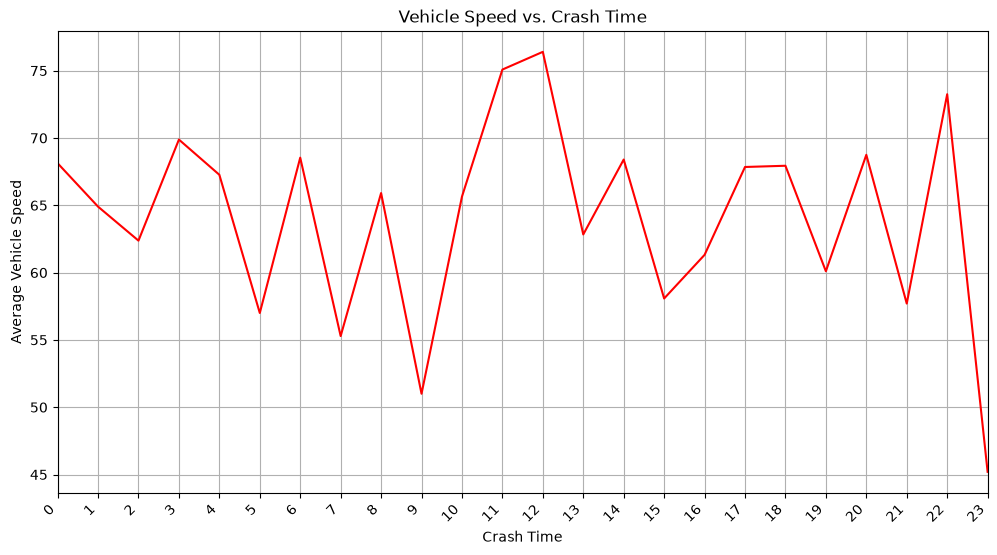

In [26]:
grouped_data = df.groupby('Crash_Time')['Vehicle_Speed'].mean().reset_index()


plt.figure(figsize=(12, 6))
sns.lineplot(x='Crash_Time', y='Vehicle_Speed', data=grouped_data,color="red")

# Set plot title and labels
plt.title('Vehicle Speed vs. Crash Time')
plt.xlabel('Crash Time')
plt.ylabel('Average Vehicle Speed')

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.xlim(0, 23)
plt.xticks(range(24))
# Show the plot
plt.show()

### Lane width histogram(with KDE)

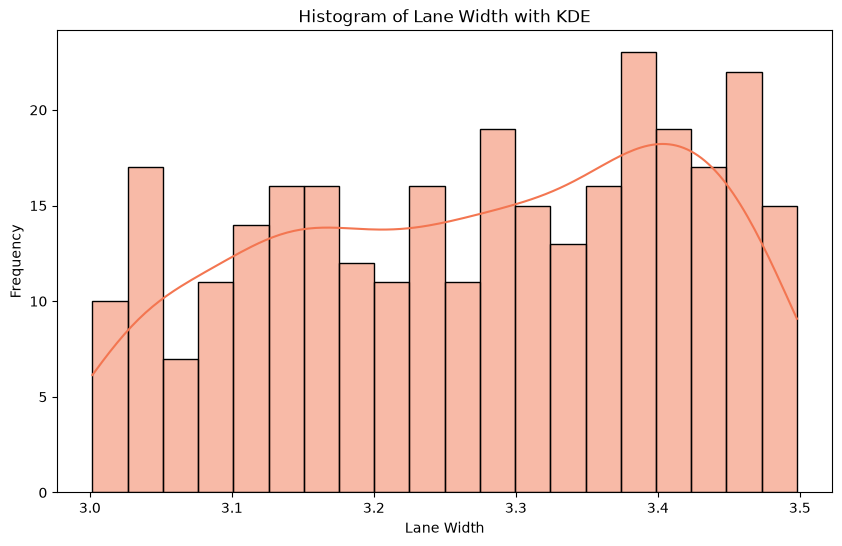

In [27]:
plt.figure(figsize=(10, 6))

# Create the histplot with KDE
sns.histplot(
    data=df,
    x='Lane_Width',
    kde=True,
    bins=20,
    color=sns.color_palette("rocket_r")[1]  # Set the color using the first color of rocket_r palette
)

# Set plot title and labels
plt.title('Histogram of Lane Width with KDE')
plt.xlabel('Lane Width')
plt.ylabel('Frequency')

# Show the plot
plt.show()

### Speed Overlimit histogram

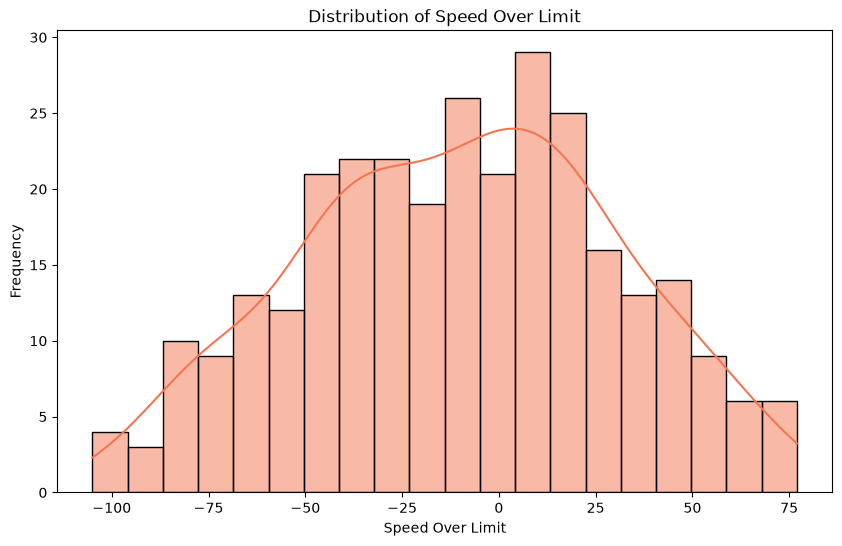

In [28]:

plt.figure(figsize=(10, 6))
sns.histplot(df['Over_Speeding'], bins=20, kde=True,color=sns.color_palette("rocket_r")[1])
plt.title('Distribution of Speed Over Limit')
plt.xlabel('Speed Over Limit')
plt.ylabel('Frequency')
plt.show()

### Over Speeding or not pie chart

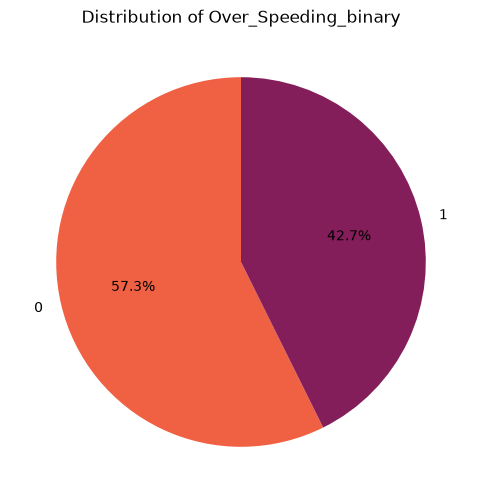

In [29]:
over_speeding_counts = df['Over_Speeding_binary'].value_counts()
colors = sns.color_palette('rocket_r', n_colors=len(over_speeding_counts))
plt.figure(figsize=(6, 6))
plt.pie(over_speeding_counts, labels=over_speeding_counts.index, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Over_Speeding_binary')
plt.show()

### Voilon plot of overspeeding by crash severity

C:\Users\Adarsh Rai\AppData\Local\Temp\ipykernel_4692\564893793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Crash_Severity', y='Over_Speeding', data=df, palette='rocket_r')


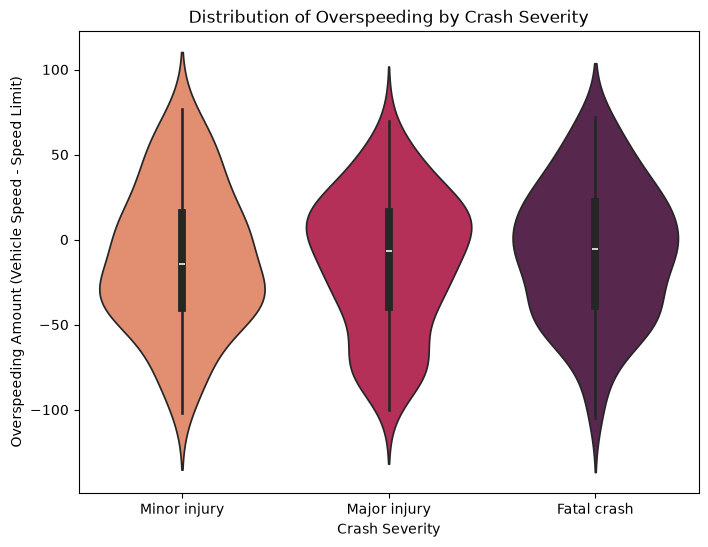

In [30]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Crash_Severity', y='Over_Speeding', data=df, palette='rocket_r')

plt.xlabel("Crash Severity")
plt.ylabel("Overspeeding Amount (Vehicle Speed - Speed Limit)")
plt.title("Distribution of Overspeeding by Crash Severity")
plt.show()

### Vehicle Speed Range by crash severity countplot

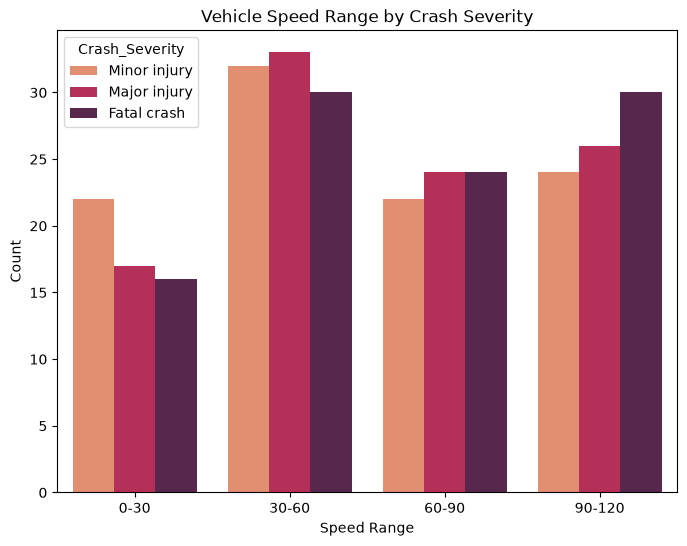

In [31]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="Vehicle_Speed_Range", hue="Crash_Severity",palette='rocket_r')
plt.title("Vehicle Speed Range by Crash Severity")
plt.xlabel("Speed Range")
plt.ylabel("Count")
plt.show()

### Pie Chart of distribution of Age Range

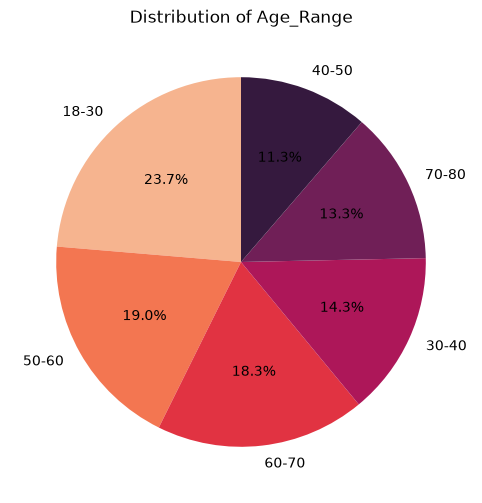

In [32]:
Age_Range_counts = df['Age_Range'].value_counts()
colors = sns.color_palette('rocket_r', n_colors=len(Age_Range_counts))

plt.figure(figsize=(6, 6))
plt.pie(Age_Range_counts, labels=Age_Range_counts.index, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Age_Range')
plt.show()


### Box plot of speed distribution by age range with crash severity

<Figure size 1200x800 with 0 Axes>

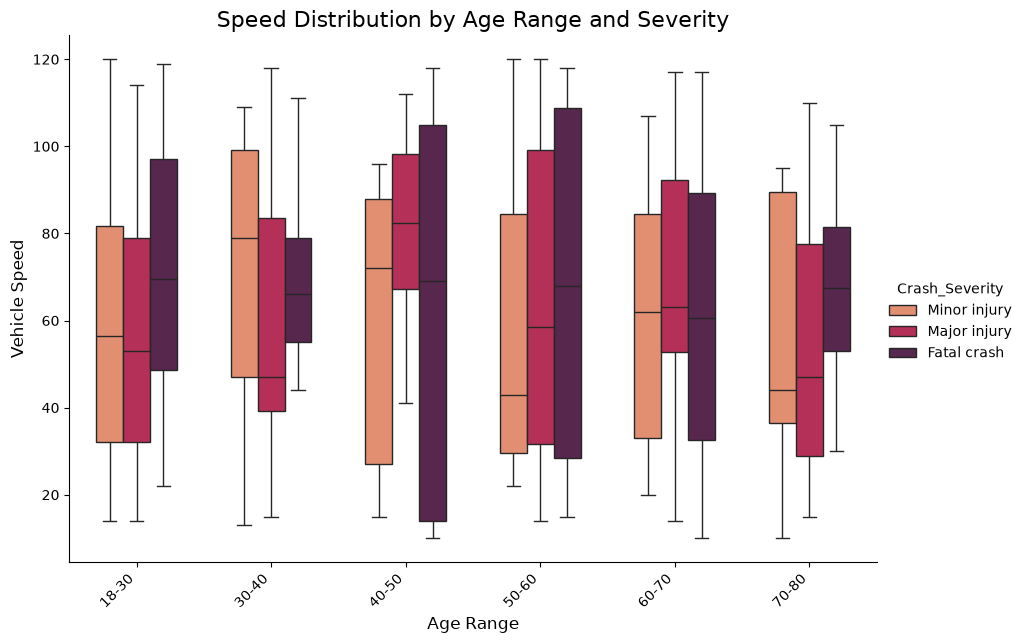

In [33]:
plt.figure(figsize=(12, 8))

sns.catplot(
    data=df,
    x="Age_Range",
    y="Vehicle_Speed",
    hue="Crash_Severity",
    kind="box",
    palette='rocket_r',
    dodge=True,
    width=0.6,
    height=6,
    aspect=1.5
)

plt.title("Speed Distribution by Age Range and Severity", fontsize=16)
plt.xlabel("Age Range", fontsize=12)
plt.ylabel("Vehicle Speed", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.show()

### Pie chart of lane width range

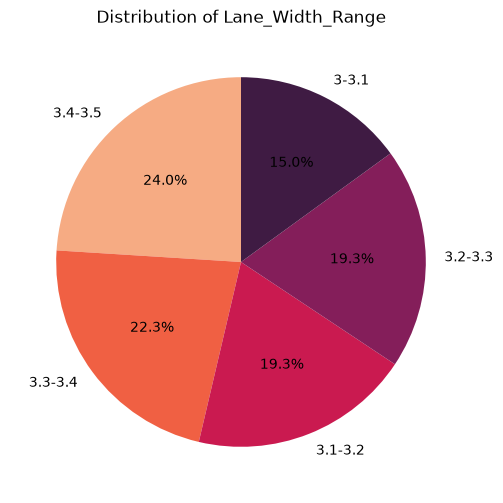

In [34]:
Lane_Width_Range_counts = df['Lane_Width_Range'].value_counts()
colors = sns.color_palette('rocket_r', n_colors=len(Lane_Width_Range_counts))

plt.figure(figsize=(6, 6))
plt.pie(Lane_Width_Range_counts, labels=Lane_Width_Range_counts.index, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Lane_Width_Range')
plt.show()

### Countplot of crash severity by lane width range

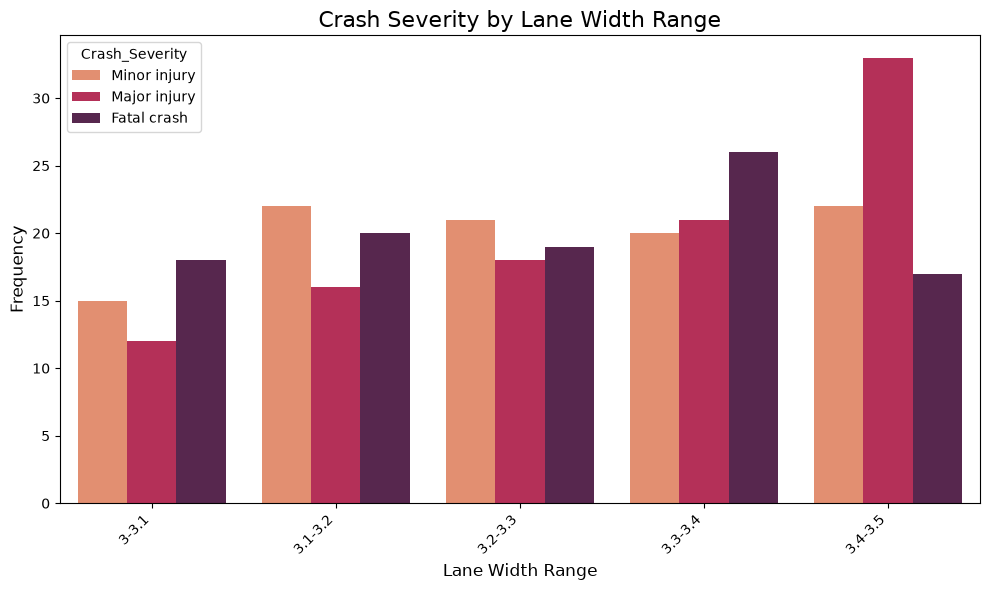

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Lane_Width_Range", hue="Crash_Severity", palette='rocket_r')
plt.title("Crash Severity by Lane Width Range", fontsize=16)
plt.xlabel("Lane Width Range", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

### Countplot of crash severity by number of lanes

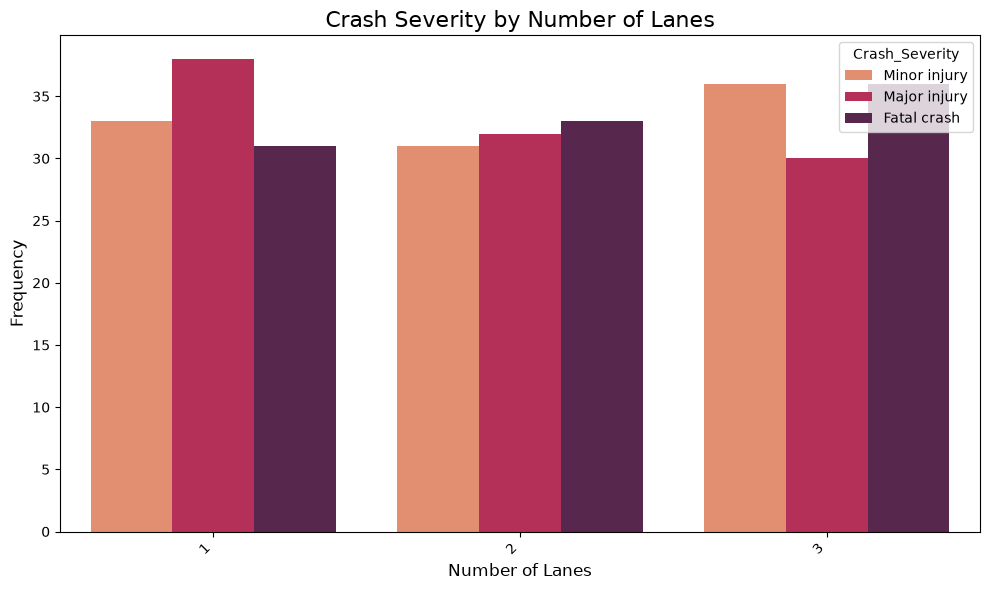

In [36]:
grouped_data = df.groupby(['Number_of_Lanes', 'Crash_Severity'])['Crash_Severity'].count().unstack()
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Number_of_Lanes", hue="Crash_Severity", palette='rocket_r')
plt.title("Crash Severity by Number of Lanes", fontsize=16)
plt.xlabel("Number of Lanes", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

### Countplot of vehicle types by number of lanes

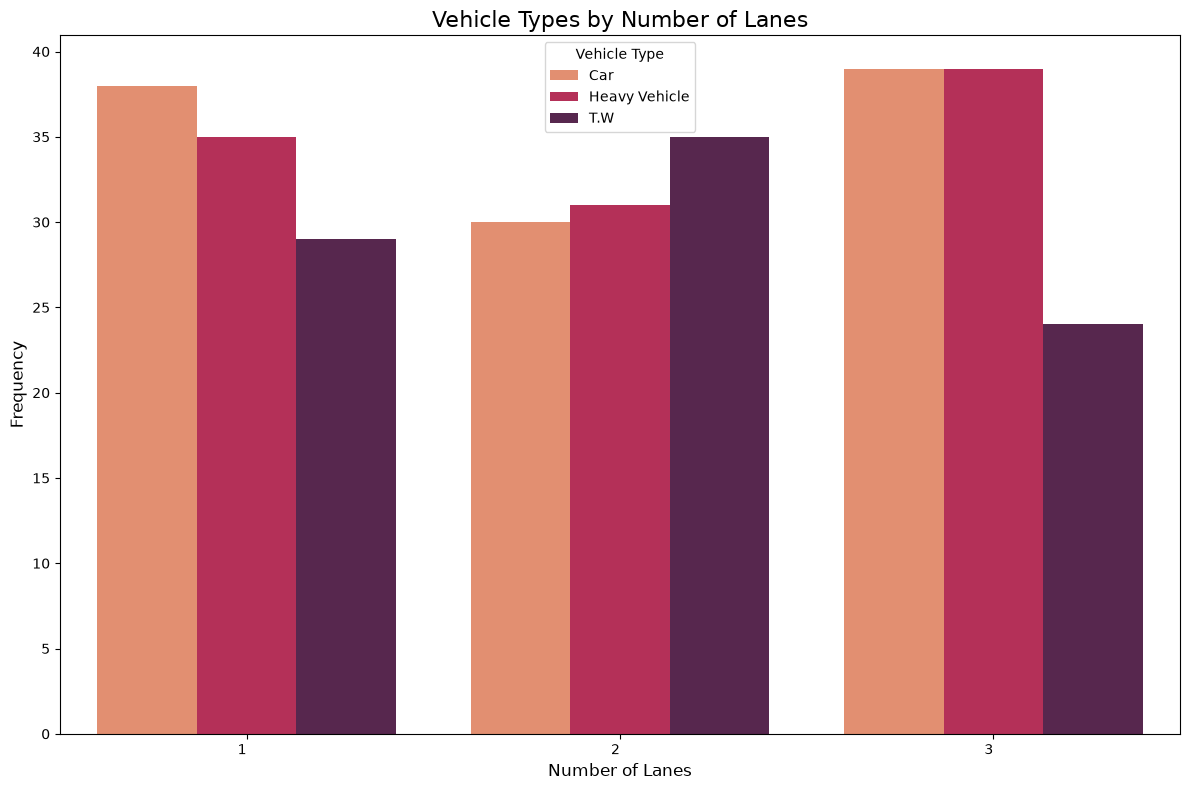

In [37]:
grouped_data = df.groupby(['Number_of_Lanes', 'Vehicle_Type'])['Vehicle_Type'].count().unstack()
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x="Number_of_Lanes", hue="Vehicle_Type", palette='rocket_r')
plt.title("Vehicle Types by Number of Lanes", fontsize=16)
plt.xlabel("Number of Lanes", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(ha='right', fontsize=10)
plt.legend(title="Vehicle Type")
plt.tight_layout()
plt.show()

### Heatmap of crash Severity by Number of Lanes and Vehicle Type

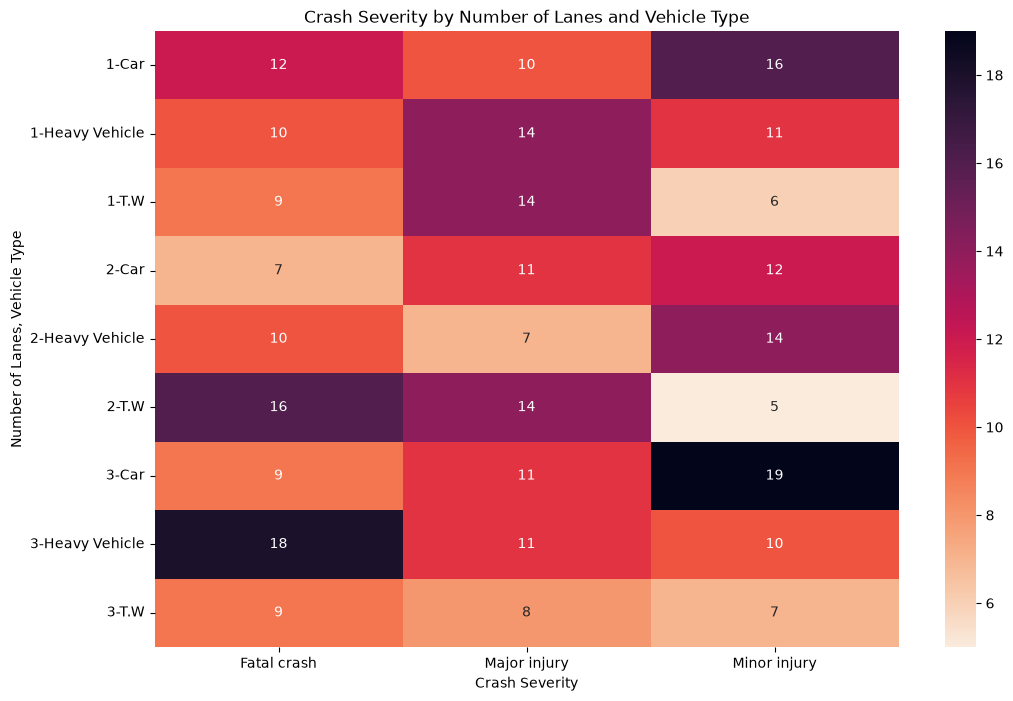

In [38]:
grouped_data = df.groupby(['Number_of_Lanes', 'Vehicle_Type', 'Crash_Severity'])['Crash_Severity'].count().reset_index(name='Count')

heatmap_data = grouped_data.pivot(index=['Number_of_Lanes', 'Vehicle_Type'], columns='Crash_Severity', values='Count').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap="rocket_r", fmt="d")
plt.title("Crash Severity by Number of Lanes and Vehicle Type")
plt.xlabel("Crash Severity")
plt.ylabel("Number of Lanes, Vehicle Type")
plt.show()

### Countplot of Overspeeding or not by Number of lanes

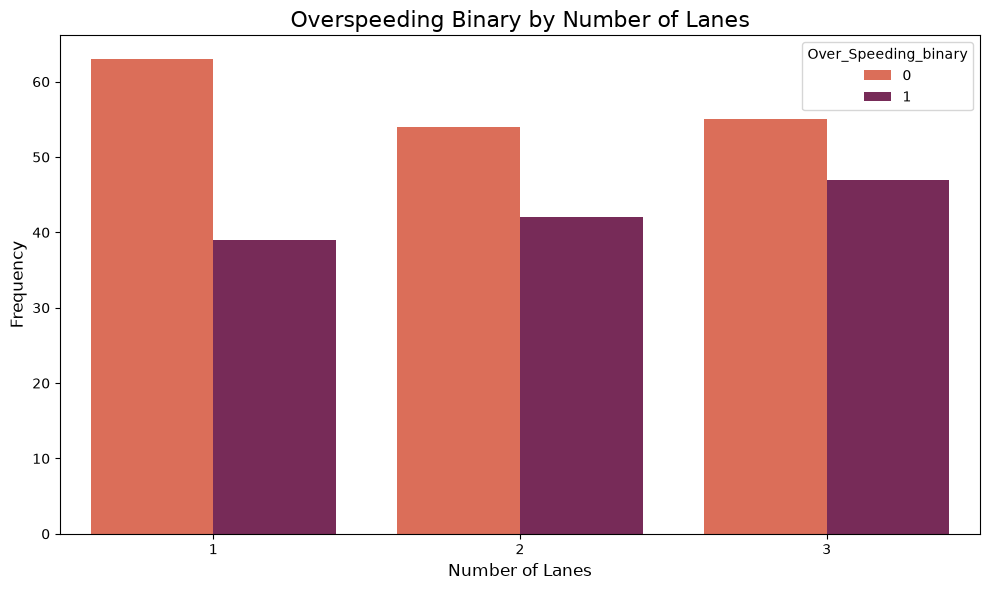

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Number_of_Lanes", hue="Over_Speeding_binary", palette='rocket_r')
plt.title("Overspeeding Binary by Number of Lanes", fontsize=16)
plt.xlabel("Number of Lanes", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

### Box plot of vehicle speed distribution by number of lanes

C:\Users\Adarsh Rai\AppData\Local\Temp\ipykernel_4692\1024127204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Number_of_Lanes", y="Vehicle_Speed", palette='rocket_r')


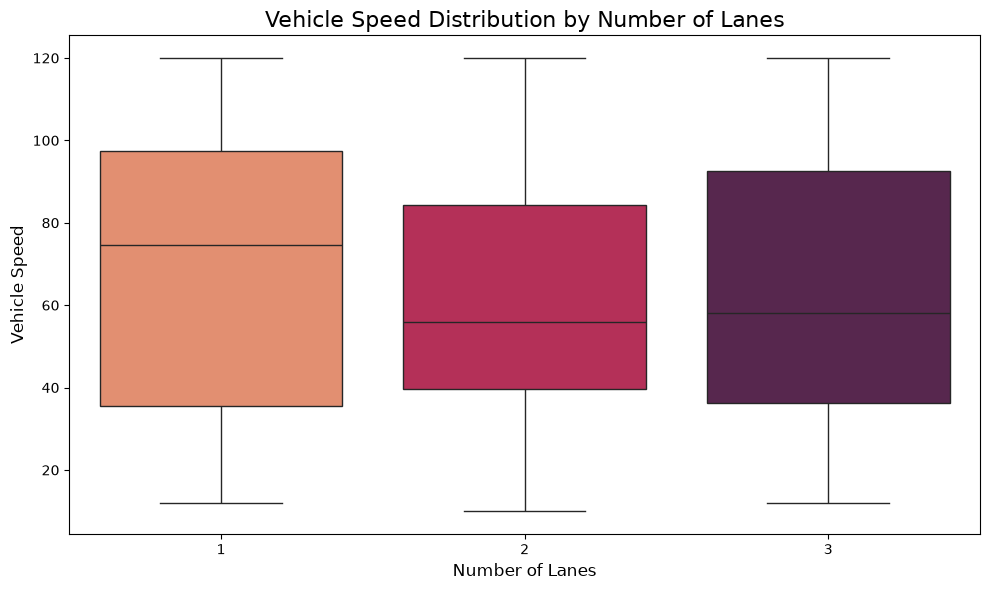

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Number_of_Lanes", y="Vehicle_Speed", palette='rocket_r')
plt.title("Vehicle Speed Distribution by Number of Lanes", fontsize=16)
plt.xlabel("Number of Lanes", fontsize=12)
plt.ylabel("Vehicle Speed", fontsize=12)
plt.tight_layout()
plt.show()

### Heatmap of Crash Severity by number of lanes and alochol consumption

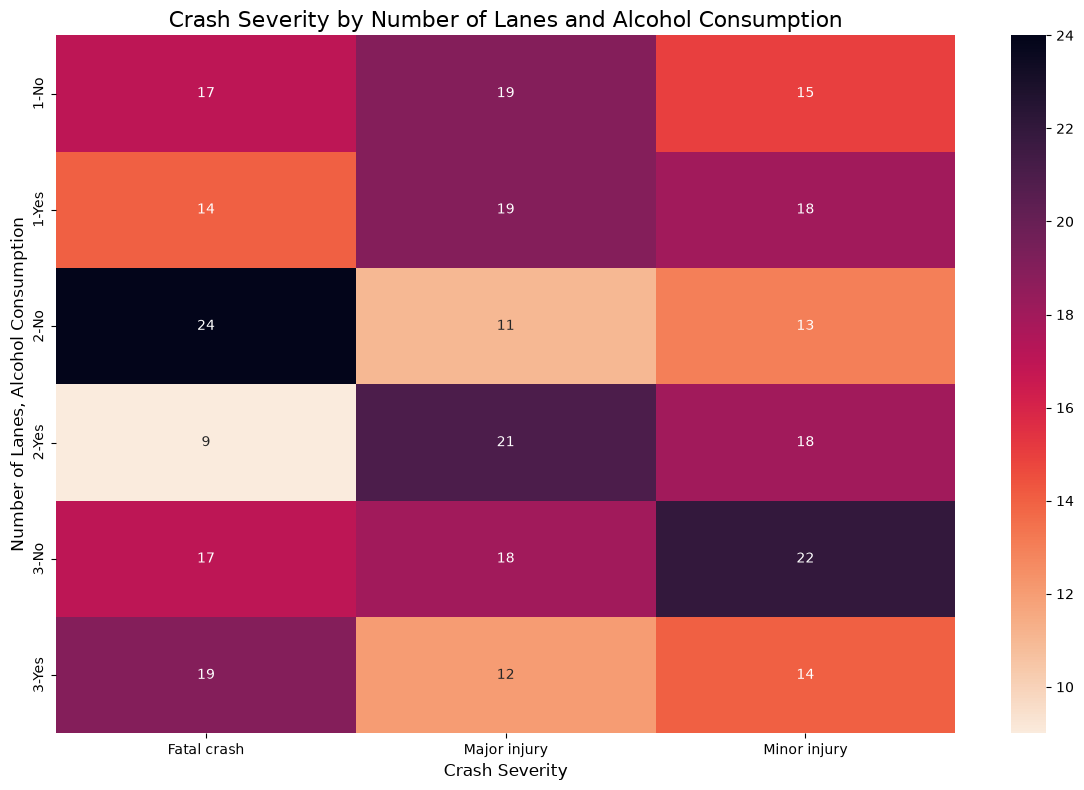

In [41]:
grouped_data = df.groupby(['Number_of_Lanes', 'Alcohol_Consumption', 'Crash_Severity'])['Crash_Severity'].count().reset_index(name='Count')

heatmap_data = grouped_data.pivot(index=['Number_of_Lanes', 'Alcohol_Consumption'],
                                 columns='Crash_Severity', values='Count').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap="rocket_r", fmt="d")
plt.title("Crash Severity by Number of Lanes and Alcohol Consumption", fontsize=16)
plt.xlabel("Crash Severity", fontsize=12)
plt.ylabel("Number of Lanes, Alcohol Consumption", fontsize=12)
plt.tight_layout()
plt.show()

### Boxplot of speedlimit by number of lanes

C:\Users\Adarsh Rai\AppData\Local\Temp\ipykernel_4692\2610233986.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Number_of_Lanes", y="Speed_Limit", palette='rocket_r')


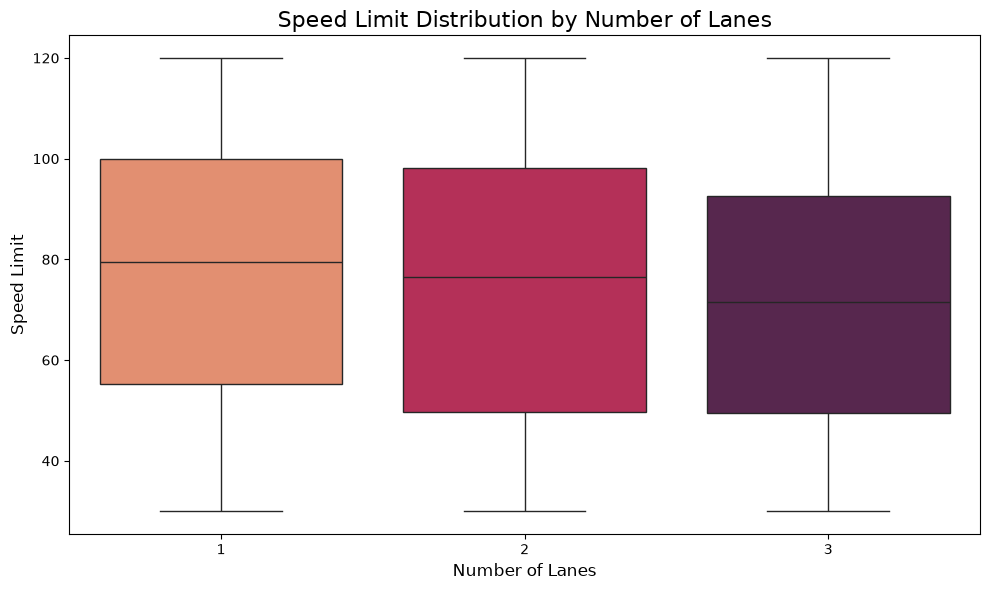

In [42]:
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.boxplot(data=df, x="Number_of_Lanes", y="Speed_Limit", palette='rocket_r')
plt.title("Speed Limit Distribution by Number of Lanes", fontsize=16)
plt.xlabel("Number of Lanes", fontsize=12)
plt.ylabel("Speed Limit", fontsize=12)
plt.tight_layout()
plt.show()

### Countplot of crash severity by lane width range

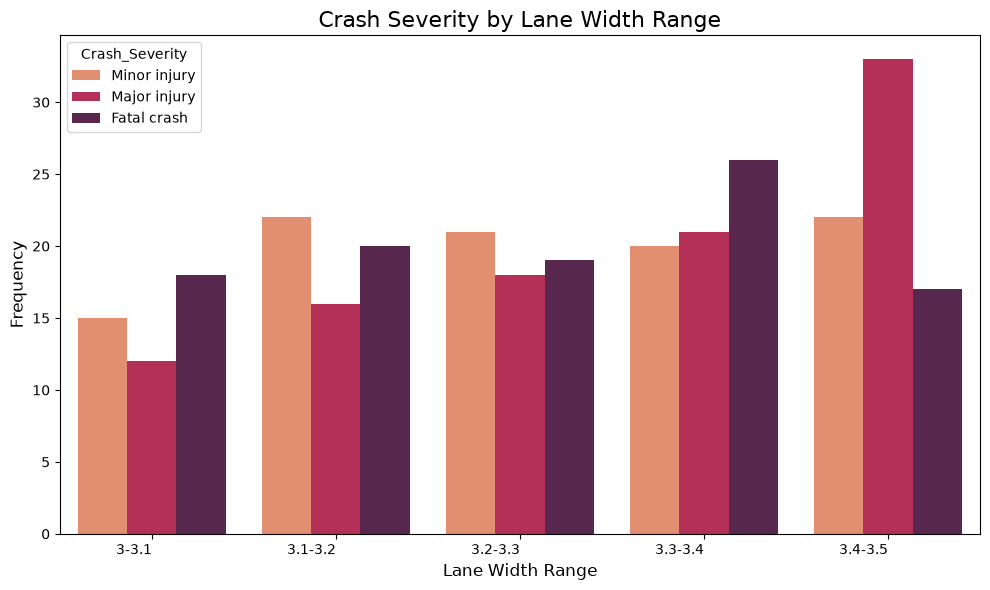

In [43]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Lane_Width_Range", hue="Crash_Severity", palette='rocket_r')
plt.title("Crash Severity by Lane Width Range", fontsize=16)
plt.xlabel("Lane Width Range", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(ha='right')
plt.tight_layout()
plt.show()

### Countplot of vehicle type by lane width range

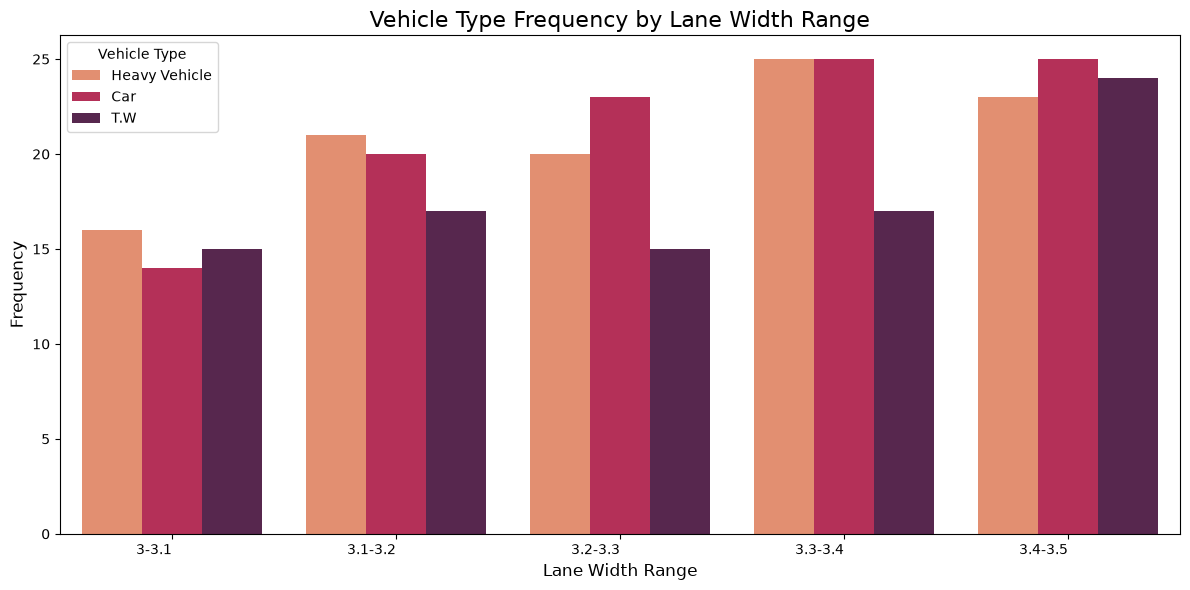

In [44]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="Lane_Width_Range", hue="Vehicle_Type", palette='rocket_r')
plt.title("Vehicle Type Frequency by Lane Width Range", fontsize=16)
plt.xlabel("Lane Width Range", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(ha='right')
plt.legend(title="Vehicle Type")
plt.tight_layout()
plt.show()

### Countplot of vehicle speed range by lane width range

C:\Users\Adarsh Rai\AppData\Local\Temp\ipykernel_4692\35803141.py:3: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.histplot(data=df, x="Vehicle_Speed_Range", hue="Lane_Width_Range",


([0, 1, 2, 3],
 [Text(0, 0, '0-30'),
  Text(1, 0, '30-60'),
  Text(2, 0, '60-90'),
  Text(3, 0, '90-120')])

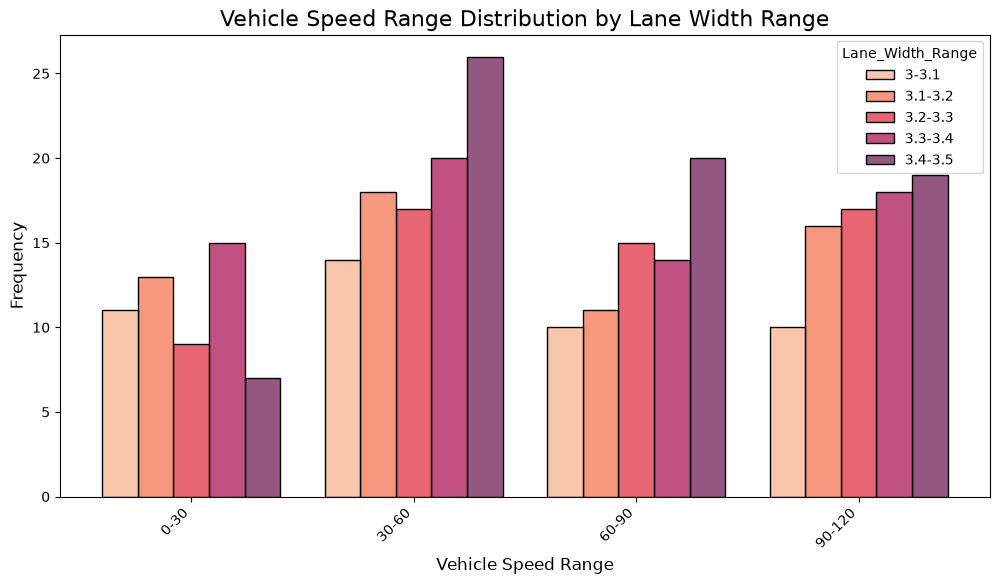

In [45]:
plt.figure(figsize=(12, 6))
rocket_cmap = sns.color_palette("rocket_r")
sns.histplot(data=df, x="Vehicle_Speed_Range", hue="Lane_Width_Range",
             multiple="dodge", shrink=.8, palette= rocket_cmap)
plt.title("Vehicle Speed Range Distribution by Lane Width Range", fontsize=16)
plt.xlabel("Vehicle Speed Range", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45, ha='right')

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Crash_Severity          300 non-null    str     
 1   Vehicle_Speed           300 non-null    int64   
 2   Crash_Time              300 non-null    int64   
 3   Age                     300 non-null    int64   
 4   Gender                  300 non-null    str     
 5   Vehicle_Type            300 non-null    str     
 6   Number_of_Lanes         300 non-null    int64   
 7   Lane_Width              300 non-null    float64 
 8   Road_Type               300 non-null    str     
 9   Alcohol_Consumption     300 non-null    str     
 10  Crash_Type              300 non-null    str     
 11  Seatbelt_Usage          300 non-null    str     
 12  Speed_Limit             300 non-null    int64   
 13  Road_Surface_Condition  300 non-null    str     
 14  Vehicle_Speed_Range     300 non-null 

## Label Encoding the Categorical Data

In [48]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [49]:
df.head()

,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Gender,Vehicle_Type,Number_of_Lanes,Lane_Width,Road_Type,Alcohol_Consumption,Crash_Type,Seatbelt_Usage,Speed_Limit,Road_Surface_Condition,Vehicle_Speed_Range,Age_Range,Lane_Width_Range,Over_Speeding,Over_Speeding_binary
0,2,107,11,27,1,1,2,3.484386,1,1,1,0,30,1,3,0,4,77,1
1,2,27,16,39,1,0,2,3.293091,0,1,1,1,110,0,0,1,2,-83,0
2,2,87,14,42,0,0,3,3.218911,1,0,1,0,59,0,2,2,2,28,1
3,2,43,3,60,0,1,2,3.113012,0,0,1,0,73,2,1,3,1,-30,0
4,2,72,8,70,1,2,3,3.106580,1,1,1,1,42,2,2,4,1,30,1


# ML Model

In [50]:
X = df.drop('Crash_Severity',axis=1)
y = df['Crash_Severity']

# Split the data into training and testing sets (stratify for class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [51]:
X.head()

,Vehicle_Speed,Crash_Time,Age,Gender,Vehicle_Type,Number_of_Lanes,Lane_Width,Road_Type,Alcohol_Consumption,Crash_Type,Seatbelt_Usage,Speed_Limit,Road_Surface_Condition,Vehicle_Speed_Range,Age_Range,Lane_Width_Range,Over_Speeding,Over_Speeding_binary
0,107,11,27,1,1,2,3.484386,1,1,1,0,30,1,3,0,4,77,1
1,27,16,39,1,0,2,3.293091,0,1,1,1,110,0,0,1,2,-83,0
2,87,14,42,0,0,3,3.218911,1,0,1,0,59,0,2,2,2,28,1
3,43,3,60,0,1,2,3.113012,0,0,1,0,73,2,1,3,1,-30,0
4,72,8,70,1,2,3,3.106580,1,1,1,1,42,2,2,4,1,30,1


In [52]:
print("Value Counts of y_train:\n", y_train.value_counts())
print("Value Counts of y_test:\n", y_test.value_counts())

Value Counts of y_train:
 Crash_Severity
0    80
1    80
2    80
Name: count, dtype: int64
Value Counts of y_test:
 Crash_Severity
0    20
2    20
1    20
Name: count, dtype: int64


## Feature Selection Strategy

In [53]:

def tune_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
    }
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(tune_rf, n_trials=100)

print(f"Best parameters for Random Forest: {study_rf.best_params}")
print(f"Best accuracy for Random Forest: {study_rf.best_value}")

[I 2026-07-29 20:35:06,170] A new study created in memory with name: no-name-27c78bb8-6897-4338-aaca-33db5bf4dcd5
[I 2026-07-29 20:35:06,955] Trial 0 finished with value: 0.4166666666666667 and parameters: {'n_estimators': 267, 'max_depth': 19, 'min_samples_split': 14, 'min_samples_leaf': 14, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.4166666666666667.
[I 2026-07-29 20:35:07,598] Trial 1 finished with value: 0.36666666666666664 and parameters: {'n_estimators': 365, 'max_depth': 20, 'min_samples_split': 19, 'min_samples_leaf': 13, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.4166666666666667.
[I 2026-07-29 20:35:07,900] Trial 2 finished with value: 0.4 and parameters: {'n_estimators': 211, 'max_depth': 17, 'min_samples_split': 30, 'min_samples_leaf': 11, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.4166666666666667.
[I 2026-07-29 20:35:08,235] Trial 3 finished with value: 0.38333333333333336 and par

Best parameters for Random Forest: {'n_estimators': 170, 'max_depth': 13, 'min_samples_split': 18, 'min_samples_leaf': 15, 'max_features': 'log2', 'bootstrap': False}
Best accuracy for Random Forest: 0.5


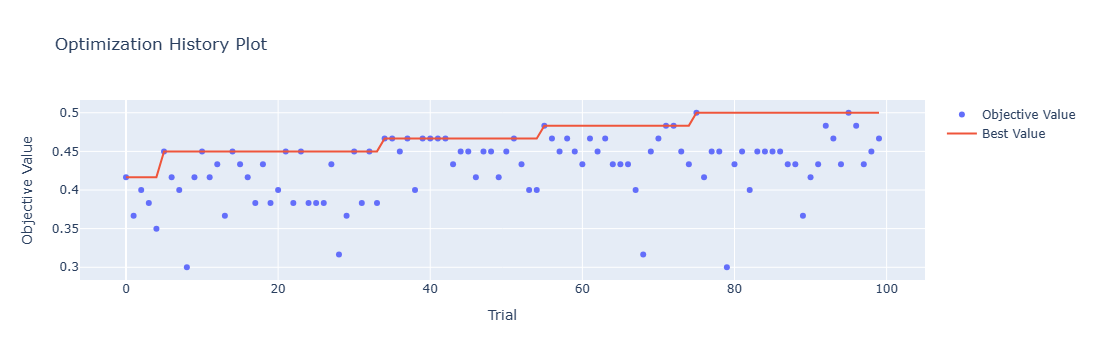

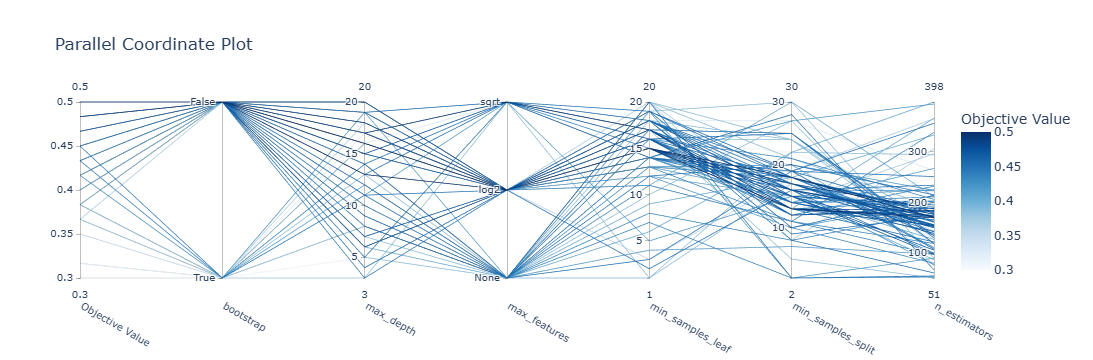

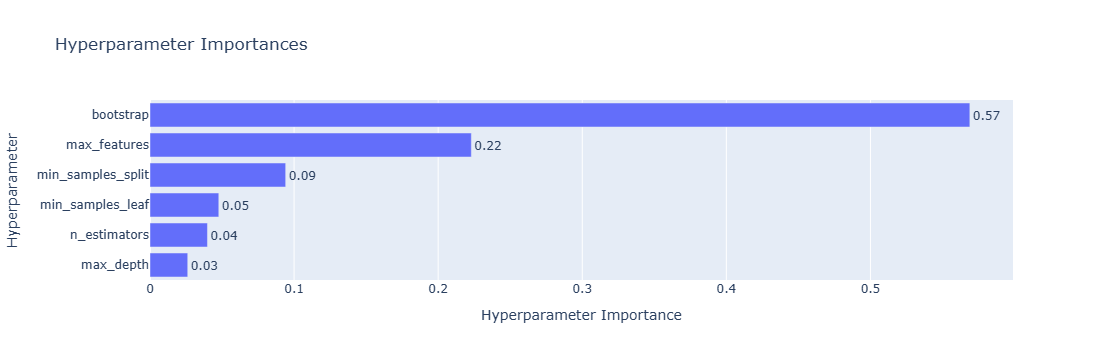

In [54]:
plot_optimization_history(study_rf).show()
plot_parallel_coordinate(study_rf).show()
plot_param_importances(study_rf).show()

In [55]:
best_params_rf = study_rf.best_params
best_params_rf

{'n_estimators': 170,
 'max_depth': 13,
 'min_samples_split': 18,
 'min_samples_leaf': 15,
 'max_features': 'log2',
 'bootstrap': False}

In [56]:
final_model_rf = RandomForestClassifier(**best_params_rf, random_state=42)
final_model_rf.fit(X_train, y_train)

y_pred = final_model_rf.predict(X_test)

report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(report)
print(cm)

              precision    recall  f1-score   support

           0       0.55      0.60      0.57        20
           1       0.42      0.40      0.41        20
           2       0.53      0.50      0.51        20

    accuracy                           0.50        60
   macro avg       0.50      0.50      0.50        60
weighted avg       0.50      0.50      0.50        60

[[12  5  3]
 [ 6  8  6]
 [ 4  6 10]]


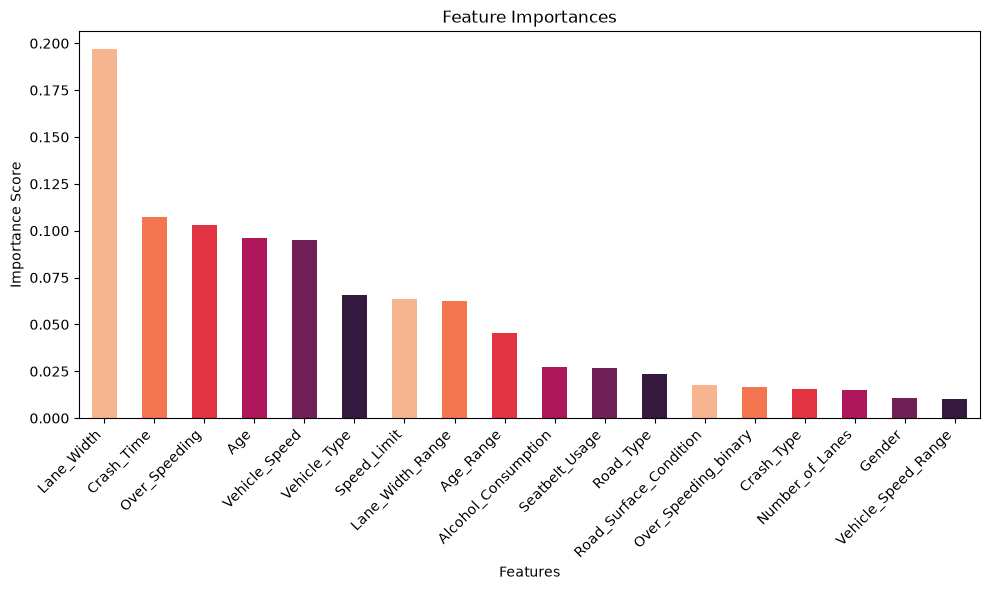

In [57]:
importances = final_model_rf.feature_importances_

feature_importances = pd.Series(importances, index=X_train.columns)

feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar', color=sns.color_palette("rocket_r"))
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

**Training the model using the top 5 features with the highest importance. This approach aims to reduce the noise captured by the model due to the inclusion of unnecessary features, thereby improving its performance.**

In [58]:
X = df[['Vehicle_Speed', 'Crash_Time', 'Age', 'Over_Speeding', 'Lane_Width']]
y = df['Crash_Severity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [59]:
X.head()

,Vehicle_Speed,Crash_Time,Age,Over_Speeding,Lane_Width
0,107,11,27,77,3.484386
1,27,16,39,-83,3.293091
2,87,14,42,28,3.218911
3,43,3,60,-30,3.113012
4,72,8,70,30,3.106580


In [60]:
print("Value Counts of y_train:\n", y_train.value_counts())
print("Value Counts of y_test:\n", y_test.value_counts())

Value Counts of y_train:
 Crash_Severity
0    80
1    80
2    80
Name: count, dtype: int64
Value Counts of y_test:
 Crash_Severity
0    20
2    20
1    20
Name: count, dtype: int64


## Random Forest

In [61]:


def tune_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 40, 200),
        "max_depth": trial.suggest_int("max_depth", 1, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
    }
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(tune_rf, n_trials=100)

print(f"Best parameters for Random Forest: {study_rf.best_params}")
print(f"Best accuracy for Random Forest: {study_rf.best_value}")

[I 2026-07-29 20:35:47,162] A new study created in memory with name: no-name-3e2cd230-75bd-4e53-ab97-8f718328daac
[I 2026-07-29 20:35:47,457] Trial 0 finished with value: 0.38333333333333336 and parameters: {'n_estimators': 154, 'max_depth': 1, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.38333333333333336.
[I 2026-07-29 20:35:47,770] Trial 1 finished with value: 0.35 and parameters: {'n_estimators': 151, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.38333333333333336.
[I 2026-07-29 20:35:47,900] Trial 2 finished with value: 0.45 and parameters: {'n_estimators': 61, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': None, 'bootstrap': True}. Best is trial 2 with value: 0.45.
[I 2026-07-29 20:35:48,285] Trial 3 finished with value: 0.38333333333333336 and parameters: {'n_estimators': 188, 'max_d

Best parameters for Random Forest: {'n_estimators': 193, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False}
Best accuracy for Random Forest: 0.5666666666666667


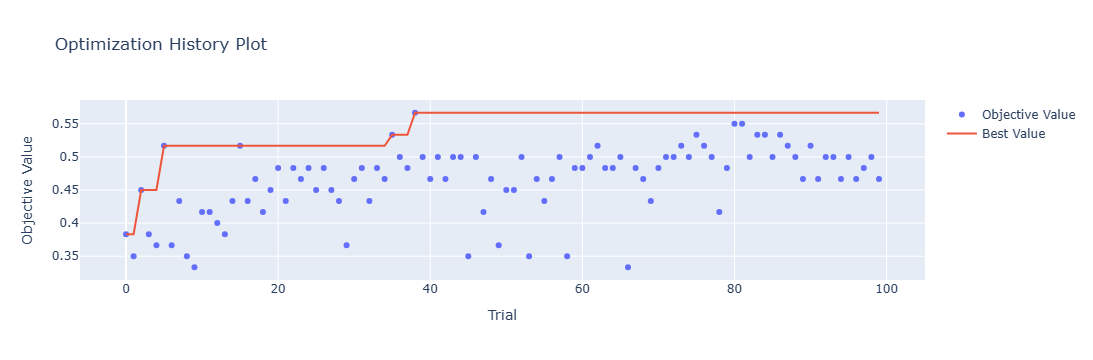

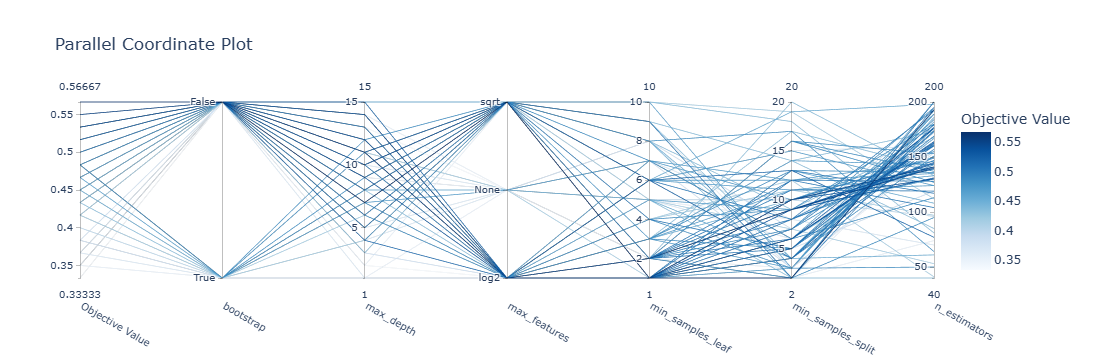

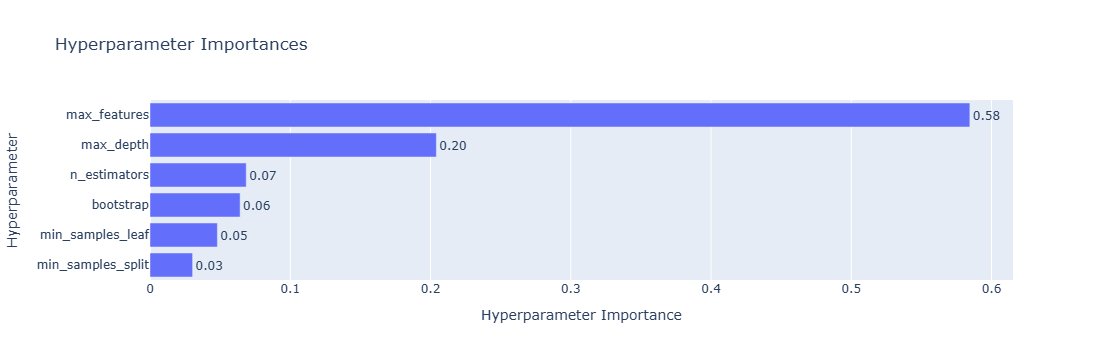

In [62]:
plot_optimization_history(study_rf).show()
plot_parallel_coordinate(study_rf).show()
plot_param_importances(study_rf).show()

In [63]:
best_params_rf = study_rf.best_params
best_params_rf

{'n_estimators': 193,
 'max_depth': 7,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'bootstrap': False}

In [64]:
final_model_rf2 = RandomForestClassifier(**best_params_rf, random_state=42)
final_model_rf2.fit(X_train, y_train)



y_pred = final_model_rf2.predict(X_test)

report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(report)
print(cm)

              precision    recall  f1-score   support

           0       0.65      0.55      0.59        20
           1       0.61      0.55      0.58        20
           2       0.48      0.60      0.53        20

    accuracy                           0.57        60
   macro avg       0.58      0.57      0.57        60
weighted avg       0.58      0.57      0.57        60

[[11  3  6]
 [ 2 11  7]
 [ 4  4 12]]


**By reducing the number of features, the model's performance improves, indicating that a larger number of features introduces noise. Therefore, we will develop the next models using a reduced set of features to enhance efficiency and accuracy.**

## XGBoost

In [65]:


def tune_xgboost(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.2, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "lambda": trial.suggest_float("lambda", 0.01, 1.0),  # L2 regularization
        "alpha": trial.suggest_float("alpha", 0.01, 1.0),  # L1 regularization
    }
    model = XGBClassifier(**params, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

study_xgboost = optuna.create_study(direction="maximize")
study_xgboost.optimize(tune_xgboost, n_trials=100)

print(f"Best parameters for XGBoost: {study_xgboost.best_params}")
print(f"Best accuracy for XGBoost: {study_xgboost.best_value}")

[I 2026-07-29 20:36:15,201] A new study created in memory with name: no-name-11b4b15a-0f14-4095-b523-a4d2f65f8180
[I 2026-07-29 20:36:16,576] Trial 0 finished with value: 0.4 and parameters: {'n_estimators': 200, 'learning_rate': 0.04033080309747411, 'max_depth': 5, 'min_child_weight': 3.3264169204253506, 'subsample': 0.32704839394862895, 'colsample_bytree': 0.8535057276474678, 'lambda': 0.7394490630538336, 'alpha': 0.726915130806857}. Best is trial 0 with value: 0.4.
[I 2026-07-29 20:36:17,187] Trial 1 finished with value: 0.3333333333333333 and parameters: {'n_estimators': 85, 'learning_rate': 0.04109102607292449, 'max_depth': 5, 'min_child_weight': 3.5408472448444215, 'subsample': 0.8198472790212885, 'colsample_bytree': 0.955283720675175, 'lambda': 0.6999136508425264, 'alpha': 0.18928936542926486}. Best is trial 0 with value: 0.4.
[I 2026-07-29 20:36:18,211] Trial 2 finished with value: 0.31666666666666665 and parameters: {'n_estimators': 269, 'learning_rate': 0.0752210485957077, 'm

Best parameters for XGBoost: {'n_estimators': 102, 'learning_rate': 0.033180546860639024, 'max_depth': 5, 'min_child_weight': 7.372801213349989, 'subsample': 0.6513621483677858, 'colsample_bytree': 0.8054165735773197, 'lambda': 0.4228321810076724, 'alpha': 0.2837761008393459}
Best accuracy for XGBoost: 0.48333333333333334


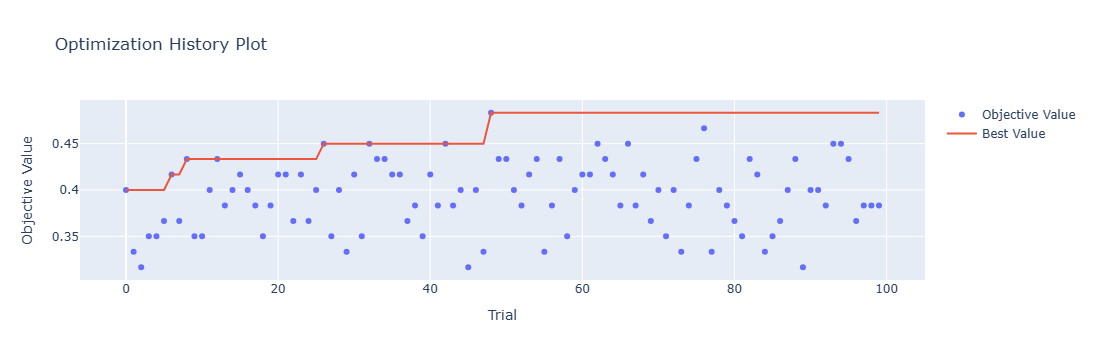

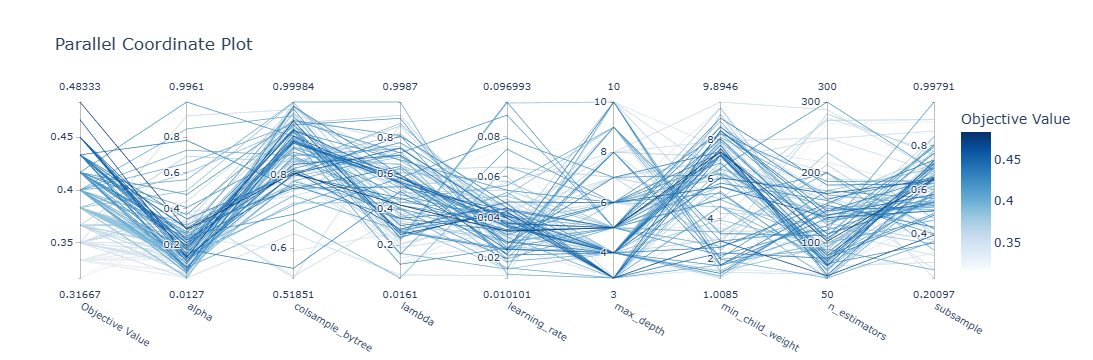

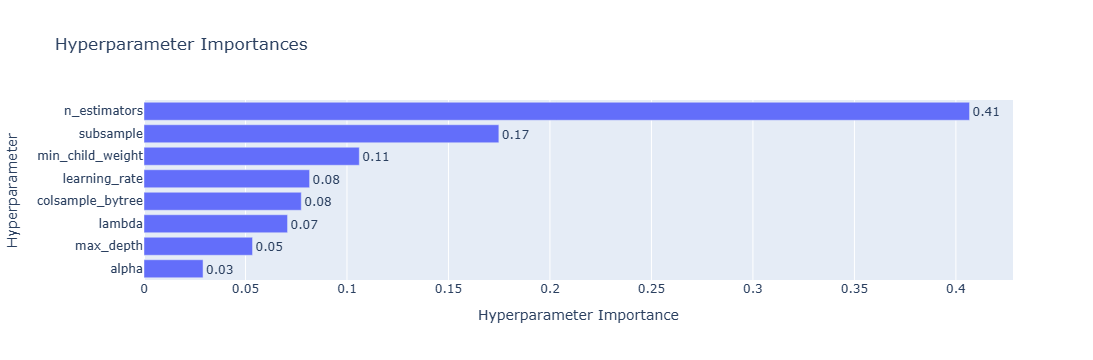

In [66]:
plot_optimization_history(study_xgboost).show()
plot_parallel_coordinate(study_xgboost).show()
plot_param_importances(study_xgboost).show()

In [67]:
best_params_xgboost = study_xgboost.best_params
best_params_xgboost

{'n_estimators': 102,
 'learning_rate': 0.033180546860639024,
 'max_depth': 5,
 'min_child_weight': 7.372801213349989,
 'subsample': 0.6513621483677858,
 'colsample_bytree': 0.8054165735773197,
 'lambda': 0.4228321810076724,
 'alpha': 0.2837761008393459}

In [68]:
final_model_xgboost = XGBClassifier(**best_params_xgboost, random_state=42)
final_model_xgboost.fit(X_train, y_train)

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_pred = final_model_xgboost.predict(X_test)

report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(report)
print(cm)

              precision    recall  f1-score   support

           0       0.53      0.50      0.51        20
           1       0.47      0.40      0.43        20
           2       0.46      0.55      0.50        20

    accuracy                           0.48        60
   macro avg       0.49      0.48      0.48        60
weighted avg       0.49      0.48      0.48        60

[[10  5  5]
 [ 4  8  8]
 [ 5  4 11]]


## LightGBM

In [69]:

def tune_lightgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 10, 50),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 2, 20),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.01, 1.0),  # L1 regularization
        "lambda_l2": trial.suggest_float("lambda_l2", 0.01, 1.0),  # L2 regularization
        "feature_fraction": trial.suggest_float("feature_fraction", 0.2, 1.0),
    }
    model = LGBMClassifier(**params, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

study_lightgbm = optuna.create_study(direction="maximize")
study_lightgbm.optimize(tune_lightgbm, n_trials=100)

print(f"Best parameters for LightGBM: {study_lightgbm.best_params}")
print(f"Best accuracy for LightGBM: {study_lightgbm.best_value}")

[I 2026-07-29 20:37:44,817] A new study created in memory with name: no-name-3f740f0d-3c9e-436d-9e66-bf4a5b45c24c


[LightGBM] [Warning] min_data_in_leaf is set=13, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=13
[LightGBM] [Warning] feature_fraction is set=0.2555440602431765, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2555440602431765
[LightGBM] [Warning] lambda_l1 is set=0.4712601399178802, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.4712601399178802
[LightGBM] [Warning] lambda_l2 is set=0.38506419743579995, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.38506419743579995
[LightGBM] [Warning] min_data_in_leaf is set=13, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=13
[LightGBM] [Warning] feature_fraction is set=0.2555440602431765, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2555440602431765
[LightGBM] [Warning] lambda_l1 is set=0.4712601399178802, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.4712601399178802
[LightGBM] [Warning] lambda_l2 is set=0.385064

[I 2026-07-29 20:37:47,311] Trial 0 finished with value: 0.31666666666666665 and parameters: {'n_estimators': 98, 'learning_rate': 0.03381486863807507, 'num_leaves': 42, 'min_data_in_leaf': 13, 'lambda_l1': 0.4712601399178802, 'lambda_l2': 0.38506419743579995, 'feature_fraction': 0.2555440602431765}. Best is trial 0 with value: 0.31666666666666665.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-07-29 20:37:48,694] Trial 1 finished with value: 0.3 and parameters: {'n_estimators': 149, 'learning_rate': 0.033519841845362976, 'num_leaves': 47, 'min_data_in_leaf': 3, 'lambda_l1': 0.5428801372619164, 'lambda_l2': 0.8392127803103374, 'feature_fraction': 0.23849320502765645}. Best is trial 0 with value: 0.31666666666666665.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-07-29 20:38:41,573] Trial 98 finished with value: 0.3333333333333333 and parameters: {'n_estimators': 57, 'learning_rate': 0.037457151553696326, 'num_leaves': 19, 'min_data_in_leaf': 20, 'lambda_l1': 0.04761352553514303, 'lambda_l2': 0.5705602358368477, 'feature_fraction': 0.900907795803363}. Best is trial 28 with value: 0.43333333333333335.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-07-29 20:38:42,028] Trial 99 finished with value: 0.4 and parameters: {'n_estimators': 75, 'learning_rate': 0.03462054062344756, 'num_leaves': 18, 'min_data_in_leaf': 15, 'lambda_l1': 0.920337512627277, 'lambda_l2': 0.7148976163463214, 'feature_fraction': 0.9216533268806297}. Best is trial 28 with value: 0.43333333333333335.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

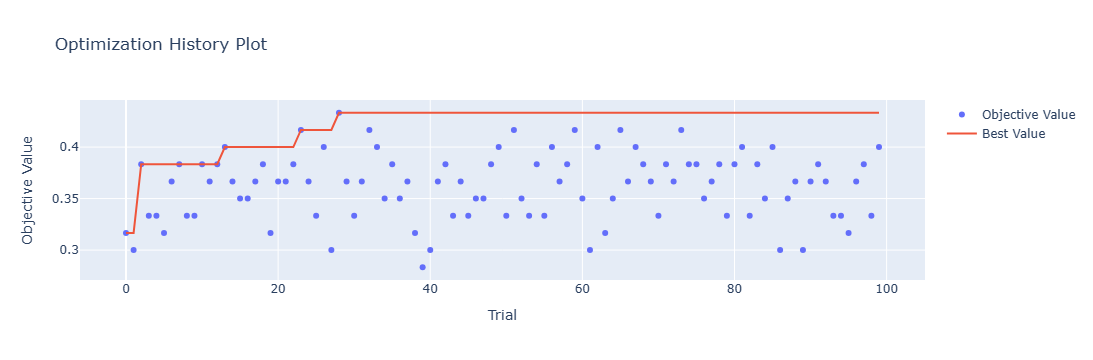

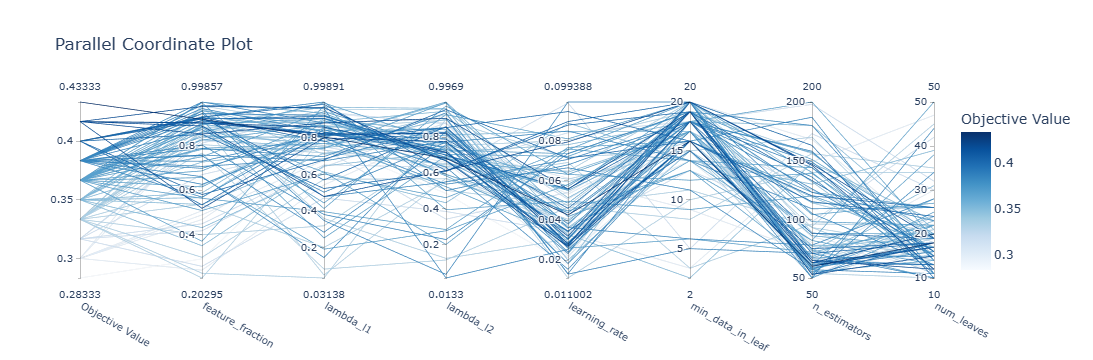

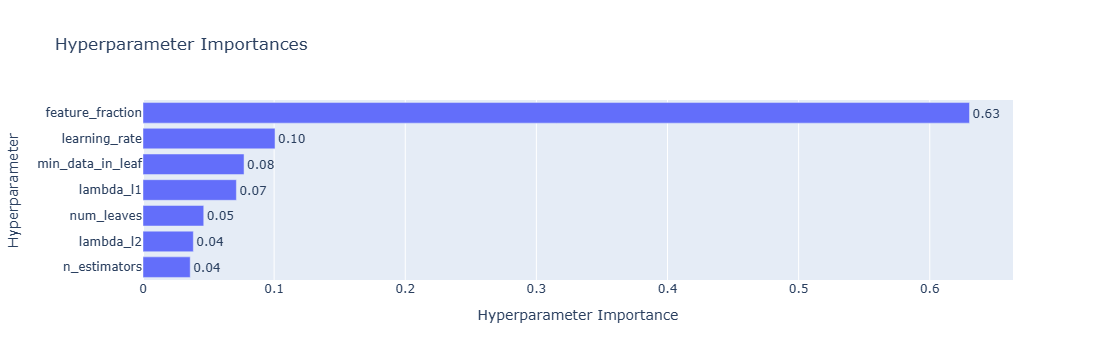

In [70]:
plot_optimization_history(study_lightgbm).show()
plot_parallel_coordinate(study_lightgbm).show()
plot_param_importances(study_lightgbm).show()

In [71]:
best_params_lightgbm = study_lightgbm.best_params
best_params_lightgbm

{'n_estimators': 60,
 'learning_rate': 0.04261748115631903,
 'num_leaves': 18,
 'min_data_in_leaf': 16,
 'lambda_l1': 0.8067860425576527,
 'lambda_l2': 0.6819630995269573,
 'feature_fraction': 0.9201829043742886}

In [72]:
final_model_lightgbm = LGBMClassifier(**best_params_lightgbm, random_state=42)
final_model_lightgbm.fit(X_train, y_train)

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_pred = final_model_lightgbm.predict(X_test)

report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(report)
print(cm)

[LightGBM] [Warning] min_data_in_leaf is set=16, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=16
[LightGBM] [Warning] feature_fraction is set=0.9201829043742886, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9201829043742886
[LightGBM] [Warning] lambda_l1 is set=0.8067860425576527, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.8067860425576527
[LightGBM] [Warning] lambda_l2 is set=0.6819630995269573, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.6819630995269573
[LightGBM] [Warning] min_data_in_leaf is set=16, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=16
[LightGBM] [Warning] feature_fraction is set=0.9201829043742886, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9201829043742886
[LightGBM] [Warning] lambda_l1 is set=0.8067860425576527, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.8067860425576527
[LightGBM] [Warning] lambda_l2 is set=0.68196309

In [73]:
print(report)
print(cm)

              precision    recall  f1-score   support

           0       0.42      0.40      0.41        20
           1       0.56      0.45      0.50        20
           2       0.36      0.45      0.40        20

    accuracy                           0.43        60
   macro avg       0.45      0.43      0.44        60
weighted avg       0.45      0.43      0.44        60

[[8 4 8]
 [3 9 8]
 [8 3 9]]


## CatBoost

In [74]:
def tune_catboost(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 2, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),  # L2 regularization
        "feature_border_type": trial.suggest_categorical("feature_border_type", ["Uniform", "MaxLogSum"]),  # Sparsity control
        "border_count": trial.suggest_int("border_count", 32, 255),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),  # Controls randomness
        "max_ctr_complexity": trial.suggest_int("max_ctr_complexity", 1, 5),  # Limits categorical feature combinations
        "random_strength": trial.suggest_float("random_strength", 1, 10),  # Adds regularization
    }
    model = CatBoostClassifier(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

study_catboost = optuna.create_study(direction="maximize")
study_catboost.optimize(tune_catboost, n_trials=150)

print(f"Best parameters for CatBoost: {study_catboost.best_params}")
print(f"Best accuracy for CatBoost: {study_catboost.best_value}")

[I 2026-07-29 20:38:43,512] A new study created in memory with name: no-name-5f613d3d-9f1f-43aa-ae5c-039f8b740555
[I 2026-07-29 20:38:45,056] Trial 0 finished with value: 0.4 and parameters: {'iterations': 82, 'learning_rate': 0.014927115362680442, 'depth': 8, 'l2_leaf_reg': 6.278661699994583, 'feature_border_type': 'Uniform', 'border_count': 106, 'bagging_temperature': 0.5645883404752223, 'max_ctr_complexity': 4, 'random_strength': 8.689919268539207}. Best is trial 0 with value: 0.4.
[I 2026-07-29 20:38:45,121] Trial 1 finished with value: 0.35 and parameters: {'iterations': 61, 'learning_rate': 0.0475471079965578, 'depth': 2, 'l2_leaf_reg': 8.140507172306265, 'feature_border_type': 'MaxLogSum', 'border_count': 78, 'bagging_temperature': 0.26149433114041076, 'max_ctr_complexity': 1, 'random_strength': 2.568751387840415}. Best is trial 0 with value: 0.4.
[I 2026-07-29 20:38:48,385] Trial 2 finished with value: 0.4 and parameters: {'iterations': 79, 'learning_rate': 0.05497443180007482,

KeyboardInterrupt: 

In [ ]:
plot_optimization_history(study_catboost).show()
plot_parallel_coordinate(study_catboost).show()
plot_param_importances(study_catboost).show()

In [ ]:
best_params_catboost = study_catboost.best_params
best_params_catboost

In [ ]:
final_model_catboost = CatBoostClassifier(**best_params_catboost, random_state=42)
final_model_catboost.fit(X_train, y_train)

y_pred = final_model_catboost.predict(X_test)

report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(report)
print(cm)

In [ ]:
print(report)
print(cm)